## Feature enginnering for Random Forest: Long Fiber

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.signal import detrend, spectrogram
import random
import matplotlib.pyplot as plt

In [2]:
def load_and_interpolate(file):

    # Read only the measurement table
    df = pd.read_csv(
        file,
        sep="\t",
        skiprows=1,
        names=["power", "time"],
        engine="python"
    )

    # Remove footer rows
    df = df[pd.to_numeric(df["power"], errors="coerce").notna()]
    
    df["power"] = pd.to_numeric(df["power"], errors="coerce")
    df["time"] = pd.to_numeric(df["time"], errors="coerce")

    df = df.dropna()

    t = df["time"].to_numpy()
    signal = df["power"].to_numpy()

    # Average sampling interval
    dt = np.mean(np.diff(t))

    # Uniform time grid
    t_uniform = np.arange(t[0], t[-1], dt)

    # Interpolate
    signal_uniform = np.interp(
        t_uniform,
        t,
        signal
    )

    # Remove mean / drift
    signal_uniform = detrend(signal_uniform)

    return t_uniform, signal_uniform

In [3]:
def process_folder(folder):

    X = []

    for file in Path(folder).glob("*.txt"):

        t, signal = load_and_interpolate(file)

        fft_features = np.abs(np.fft.rfft(signal))[1:150]

        if len(fft_features) != 149:
            print(f"Warning: {file} produced {len(fft_features)} bins")

        X.append(fft_features)

    return np.array(X)

In [4]:
X_UG_dig = process_folder("Saved data/UG_dig")
X_UG_drill= process_folder("Saved data/UG_drill")
X_UG_step  = process_folder("Saved data/UG_step")

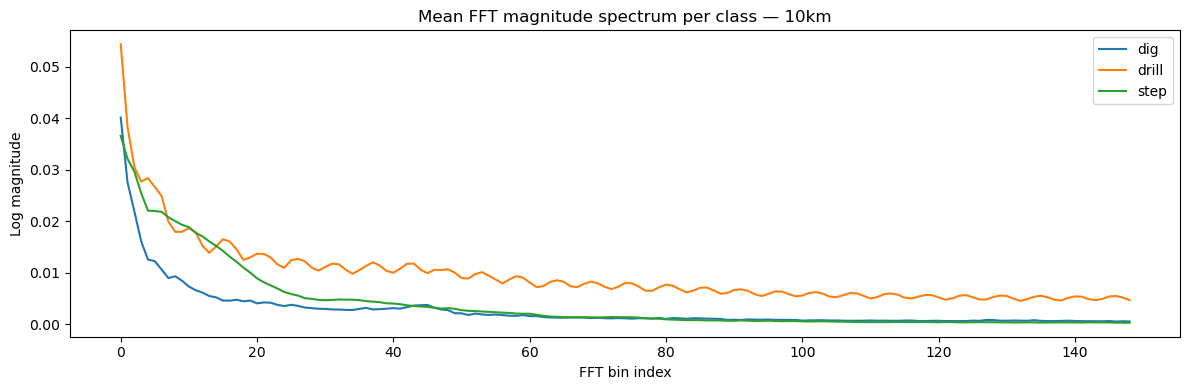

In [5]:
# Mean FFT per class — log scale since we already know linear can be misleading
plt.figure(figsize=(12, 4))
plt.plot(np.log1p(X_UG_dig.mean(axis=0)), label="dig")
plt.plot(np.log1p(X_UG_drill.mean(axis=0)), label="drill")
plt.plot(np.log1p(X_UG_step.mean(axis=0)), label="step")
plt.xlabel("FFT bin index")
plt.ylabel("Log magnitude")
plt.title("Mean FFT magnitude spectrum per class — 10km")
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
def plot_spectrograms(folder, label, n=3):
    all_files = list(Path(folder).glob("*.txt"))
    files = random.sample(all_files, min(n, len(all_files)))
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    
    for ax, file in zip(axes, files):
        t, signal = load_and_interpolate(file)
        dt = np.mean(np.diff(t))
        fs = 1 / dt
        
        f, tt, Sxx = spectrogram(signal, fs=fs, nperseg=64, noverlap=32)
        ax.pcolormesh(tt, f, 10*np.log10(Sxx + 1e-10), cmap="viridis")
        ax.set_xlabel("Time [s]")
        ax.set_ylabel("Frequency [Hz]")
        ax.set_title(f"{label} — {file.name}")
    
    plt.suptitle(f"Spectrograms: {label}")
    plt.tight_layout()
    plt.show()

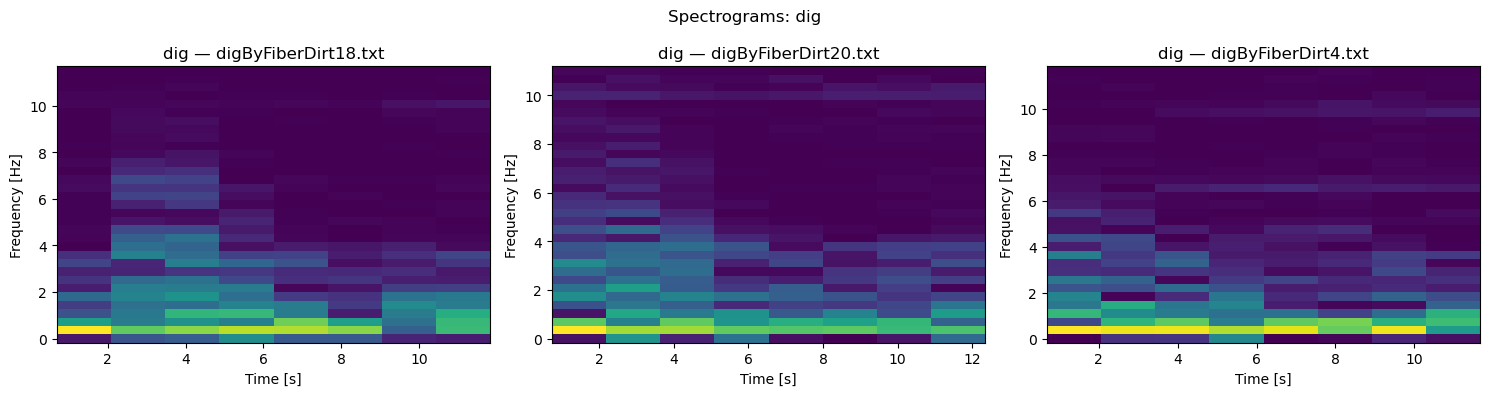

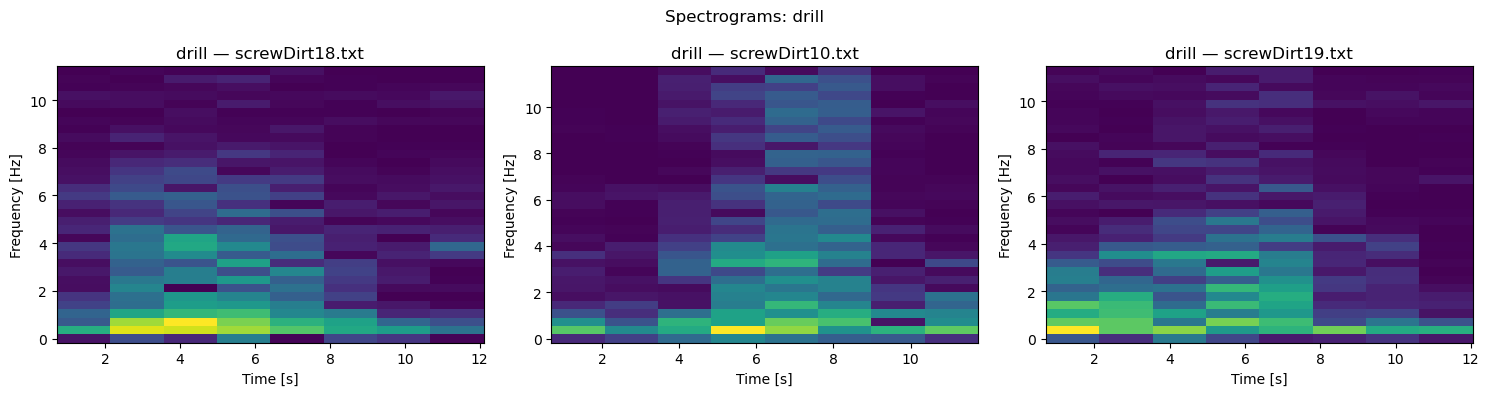

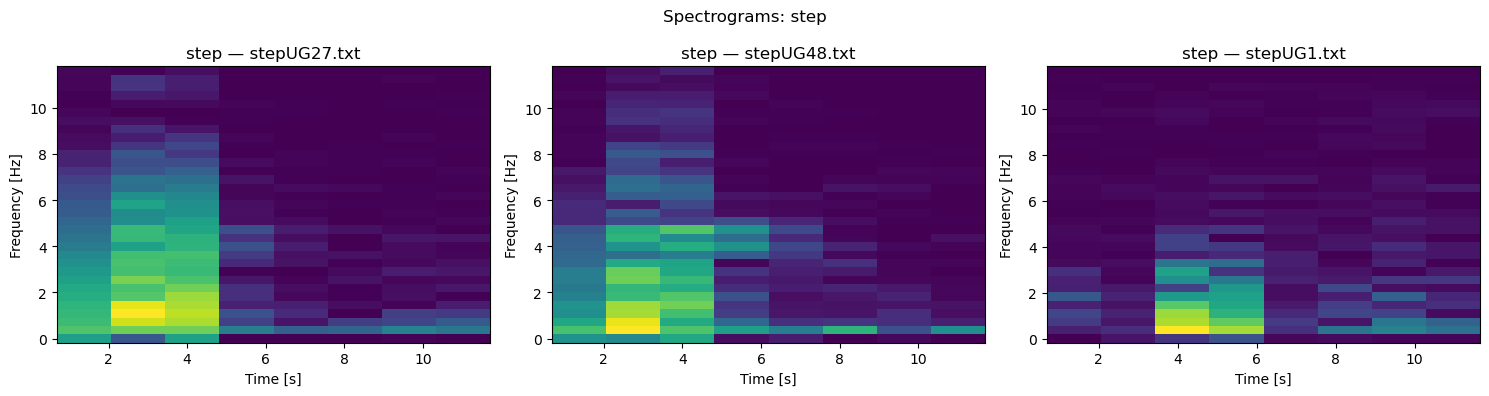

In [7]:
plot_spectrograms("Saved data/UG_dig", "dig")
plot_spectrograms("Saved data/UG_drill", "drill")
plot_spectrograms("Saved data/UG_step", "step")

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

##### Feature engineering:

In [9]:
def extract_features(signal, fs):
    features = {}
    
    freqs = np.fft.rfftfreq(len(signal), d=1/fs)
    fft_mag = np.abs(np.fft.rfft(signal))
    
    features["total_energy"] = np.sum(signal**2)
    features["peak_magnitude"] = np.max(np.abs(signal))
    features["rms"] = np.sqrt(np.mean(signal**2))
    
    low  = (freqs >= 0) & (freqs < 2)
    mid  = (freqs >= 2) & (freqs < 6)
    high = (freqs >= 6)

    energy_low  = np.sum(fft_mag[low]**2)
    energy_mid  = np.sum(fft_mag[mid]**2)
    energy_high = np.sum(fft_mag[high]**2)

    features["energy_low"]       = energy_low
    features["energy_mid"]       = energy_mid
    features["energy_high"]      = energy_high
    features["low_to_mid_ratio"] = energy_low / (energy_mid + 1e-10)
    features["low_to_high_ratio"]= energy_low / (energy_high + 1e-10)
    
    # Shake has proportionally more high frequency energy than tap
    high = (freqs >= 6) & (freqs < 11)
    mid = (freqs >= 2) & (freqs < 6)
    features["mid_to_high_ratio"] = np.sum(fft_mag[mid]**2) / (np.sum(fft_mag[high]**2) + 1e-10)

    # Shake stays active longer than tap
    threshold = 2 * np.std(signal)
    features["burst_duration"] = np.sum(np.abs(signal) > threshold) / fs
    
    # Blow = many crossings (fragmented), tap = few (one clean burst)
    threshold = 2 * np.std(signal)
    crossings = np.sum(np.diff((np.abs(signal) > threshold).astype(int)) != 0)
    features["threshold_crossings"] = crossings

    # How concentrated is the energy in time?
    # Tap = one spike so std of active signal is low, Blow = scattered so energy is more evenly spread
    energy_envelope = signal**2
    features["energy_concentration"] = np.max(energy_envelope) / (np.mean(energy_envelope) + 1e-10)

    # How sharp is the main peak?
    # Tap = one clean sharp peak, blow = multiple smaller peaks
    features["peak_to_rms"] = np.max(np.abs(signal)) / (np.sqrt(np.mean(signal**2)) + 1e-10)
    
    return features

In [10]:
def process_folder_features(folder):
    rows = []
    for file in Path(folder).glob("*.txt"):
        if file.name.lower().startswith("readme"):
            continue
        try:
            t, signal = load_and_interpolate(file)
            dt = np.mean(np.diff(t))
            fs = 1 / dt
            feats = extract_features(signal, fs)
            rows.append(feats)
        except Exception as e:
            print(f"FAILED: {file.name} — {e}")

    return pd.DataFrame(rows)  # each row = one file, each column = one feature

In [11]:
df_dig  = process_folder_features("Saved data/UG_dig")
df_drill = process_folder_features("Saved data/UG_drill")
df_step   = process_folder_features("Saved data/UG_step")

df_dig["label"]  = 0
df_drill["label"] = 1
df_step["label"]   = 2

df_all = pd.concat([df_dig, df_drill, df_step], ignore_index=True)

X = df_all.drop(columns="label").values
y = df_all["label"].values

              precision    recall  f1-score   support

         dig       0.78      0.70      0.74        10
       drill       0.73      0.80      0.76        10
        step       0.90      0.90      0.90        10

    accuracy                           0.80        30
   macro avg       0.80      0.80      0.80        30
weighted avg       0.80      0.80      0.80        30



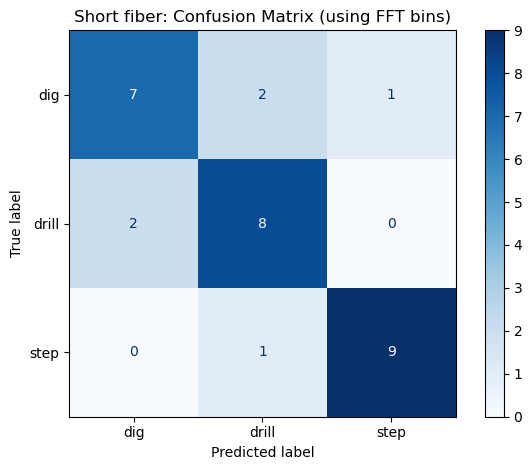

In [14]:
# Then identical to before
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

clf = RandomForestClassifier(n_estimators=200)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["dig", "drill", "step"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["dig", "drill", "step"])
disp.plot(cmap="Blues")
plt.title("Short fiber: Confusion Matrix (using FFT bins)")
plt.tight_layout()
#plt.savefig("confusion_matrix4.png", dpi=150)
plt.show()

In [15]:
cv_scores = cross_val_score(clf, X, y, cv=5, scoring="accuracy")
print(f"Cross-validation accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Individual folds: {cv_scores}")

Cross-validation accuracy: 0.653 ± 0.096
Individual folds: [0.73333333 0.66666667 0.46666667 0.7        0.7       ]


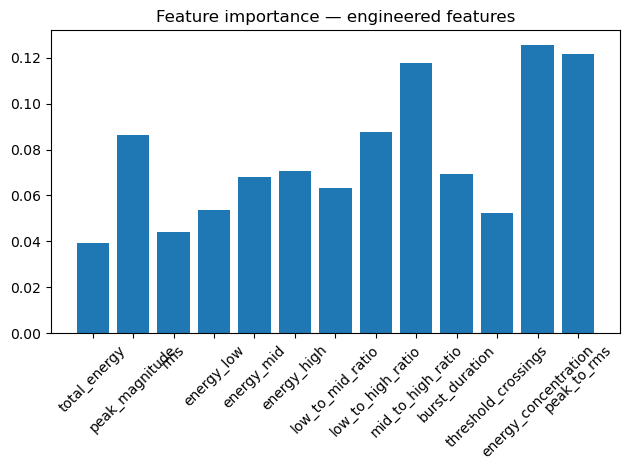

In [16]:
feature_names = df_all.drop(columns="label").columns
importances = clf.feature_importances_

plt.bar(feature_names, importances)
plt.xticks(rotation=45)
plt.title("Feature importance — engineered features")
plt.tight_layout()
plt.show()